C:\Users\cpope\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\cpope\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


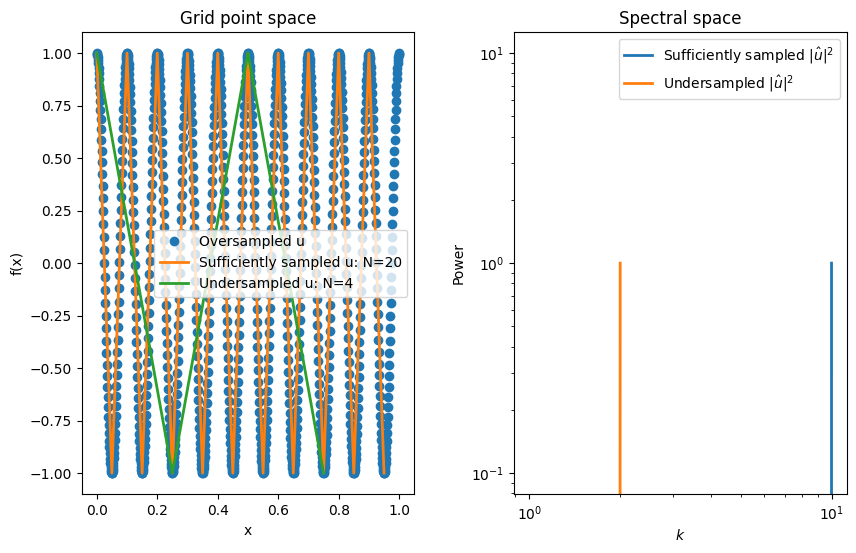

In [1]:
import numpy as np
import scipy.fft as ft
import matplotlib.pyplot as plt

pi = np.pi
L = 1
N = 20
N1 = 4

y = np.linspace(0, L, 1000)
x = np.linspace(0, L, N, endpoint=False)
x1 = np.linspace(0, L, N1, endpoint=False)

u1 = np.cos(2 * 10 * pi * y / L)
u = np.cos(2 * 10 * pi * x / L)
v = np.cos(2 * 10 * pi * x1 / L)

vhat = ft.rfft(v, norm="forward")
uhat = ft.rfft(u, norm="forward")

u2 = uhat * np.conj(uhat)
v2 = vhat * np.conj(vhat)

fig = plt.figure(figsize=(9, 6))

ax1 = plt.subplot(1, 2, 1)
ax1.plot(y, u1, "o", label="Oversampled u")
ax1.plot(x, u, label=f"Sufficiently sampled u: N={N}", linewidth=2)
ax1.plot(x1, v, label=f"Undersampled u: N={N1}", linewidth=2)
ax1.set_xlabel("x")
ax1.set_ylabel("f(x)")
ax1.set_title("Grid point space")
ax1.legend()

ax2 = plt.subplot(1, 2, 2)
k = np.arange(len(uhat))
k1 = np.arange(len(vhat))

ax2.loglog(k[1:], u2[1:], label="Sufficiently sampled $|\\hat u|^2$", linewidth=2)
ax2.loglog(k1[1:], v2[1:], label="Undersampled $|\\hat u|^2$", linewidth=2)
ax2.set_xlabel("$k$")
ax2.set_ylabel("Power")
ax2.set_title("Spectral space")
ax2.legend()

plt.subplots_adjust(left=0.12, right=0.97, wspace=0.3)
plt.show()


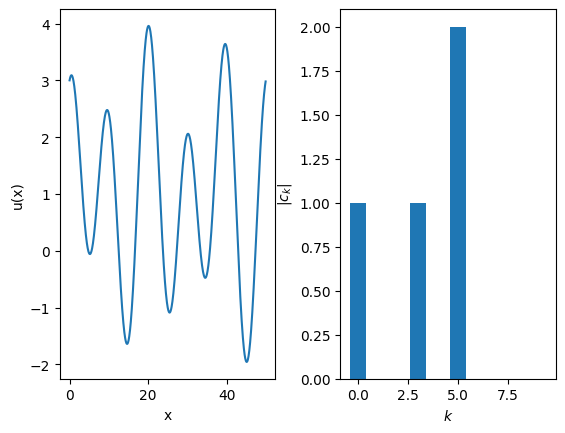

In [11]:
import numpy as np
import scipy.fft as ft
import matplotlib.pyplot as plt

pi = np.pi
L = 50

x = np.linspace(0, L, 1000, endpoint=False)
u = 1 + np.sin(2 * pi * x * 3 / L) + 2 * np.cos(2 * pi * x * 5 / L)

uhat = ft.rfft(u, norm="forward")  # compute real FFT of u

ck = 2 * uhat
ck[0] = ck[0] / 2
# For positive harmonics, multiply u(k) for k > 0 by 2

ax1 = plt.subplot(1, 2, 1)
ax1.plot(x, u)
ax1.set_xlabel("x")
ax1.set_ylabel("u(x)")

ax2 = plt.subplot(1, 2, 2)
k = np.arange(len(uhat))
ax2.bar(x=k[0:10], height=np.abs(ck[0:10]))
ax2.set_xlabel("$k$")
ax2.set_ylabel("$|c_k|$")

plt.subplots_adjust(wspace=0.3)
plt.show()


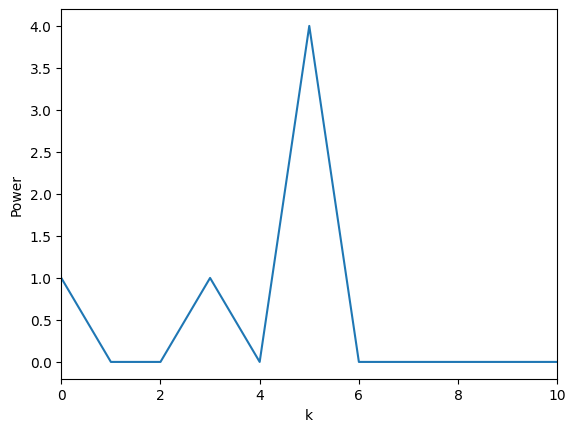

In [18]:
import numpy as np
import scipy.fft as ft
import matplotlib.pyplot as plt

uhat = ft.rfft(u, norm="forward")  # compute real FFT of u
ck = 2 * uhat

# Correct the DC term (k = 0) because it should not be doubled
ck[0] = ck[0] / 2

plt.plot(ck * np.conj(ck))
plt.xlim([0, 10])
plt.xlabel("k")
plt.ylabel("Power")
plt.show()
